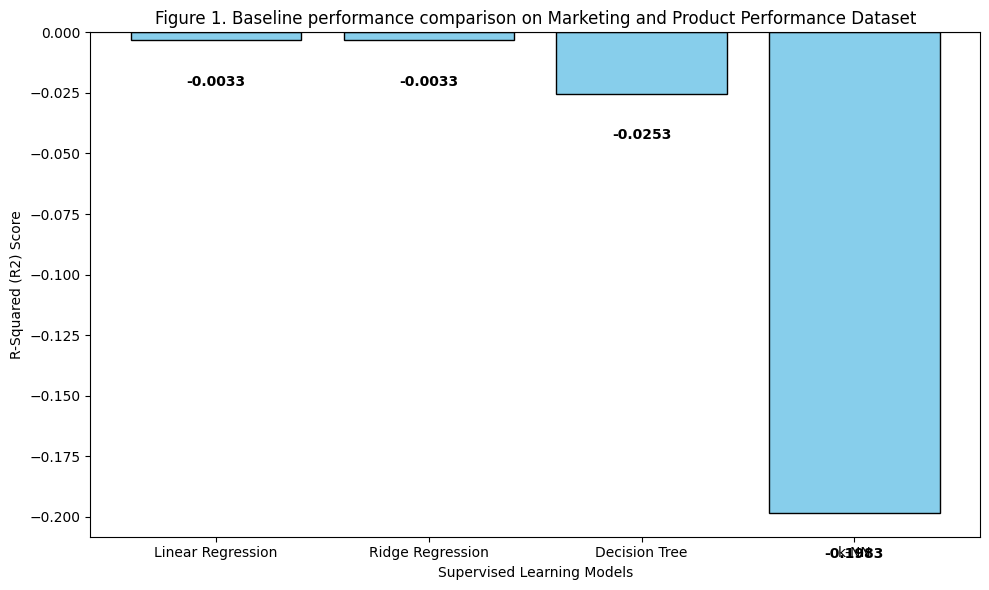

Notebook 1 Complete. Files saved in /kaggle/working/


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset from Kaggle path
# Ensure you have added the dataset to your Kaggle notebook first
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

# 2. Data Cleaning
# Hum unique IDs ko drop kar rahe hain kyunki ye prediction mein madad nahi karte
cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
df_clean = df.drop(columns=cols_to_drop)

# Categorical data (Subscription_Tier) ko numbers mein convert karna (One-Hot Encoding)
df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)

# 3. Define Features (X) and Target (y)
# Target variable 'Revenue_Generated' hai jaisa ki instructor ne sample mein bataya
X = df_clean.drop(columns=['Revenue_Generated'])
y = df_clean['Revenue_Generated']

# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize Baseline Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "k-NN": KNeighborsRegressor(n_neighbors=5)
}

# 6. Training and Evaluation Loop
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4),
        "Notes": "Baseline" if "Regression" in name else ("Nonlinear" if "Tree" in name else "Instance-based")
    })

# 7. Export Results Table to CSV (Step-by-step Methodology requirement)
table_rq1 = pd.DataFrame(results)
table_rq1.to_csv('RQ1_Baseline_Table.csv', index=False)

# 8. Generate and Save Figure as PDF (IEEE Publication standard)
plt.figure(figsize=(10, 6))
bars = plt.bar(table_rq1["Model"], table_rq1["R2"], color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Figure 1. Baseline performance comparison on Marketing and Product Performance Dataset')
plt.ylabel('R-Squared (R2) Score')
plt.xlabel('Supervised Learning Models')

# Add values on top of bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005 if yval > 0 else yval - 0.02, 
             yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('RQ1_Baseline_Figure.pdf')
plt.show()

print("Notebook 1 Complete. Files saved in /kaggle/working/")